# CS 363M Machine Learning Project
## Wildlife Strike Damage Prediction

This notebook builds a full tabular-ML workflow for the Kaggle competition:

- audit the raw training/test data
- clean missing values and mixed data types
- engineer features motivated by aviation context
- compare multiple models with the course metric (`balanced accuracy`)
- tune the strongest boosting model with stratified cross-validation
- generate final competition predictions without modifying the input CSV files

## Modeling Philosophy

A few choices shaped the workflow below:

- The target is **highly imbalanced**, so plain accuracy is not trustworthy. We optimize and report **balanced accuracy** throughout.
- We avoid raw free-text NLP. The competition is a structured-data problem, so the notebook stays inside course topics: cleaning, feature engineering, classification, trees, boosting, class imbalance handling, and cross-validation.
- We use **cross-validated out-of-fold (OOF)** predictions to choose the final threshold and to compare the strongest boosting settings without over-relying on a single validation split.
- We keep the notebook organized so it can double as a walkthrough document for the professor.

In [24]:
!pip install seaborn 

In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from textwrap import dedent

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
DATA_DIR = Path(".")
USE_TEXT_METADATA = True
SAVE_SUBMISSION = True

In [26]:
train_df = pd.read_csv(DATA_DIR / "train.csv", low_memory=False)
test_df = pd.read_csv(DATA_DIR / "test.csv", low_memory=False)
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

target_col = "INDICATED_DAMAGE"

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"Submission shape: {sample_submission.shape}")
display(train_df.head())

Train shape: (307178, 55)
Test shape:  (34131, 54)
Submission shape: (34131, 2)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0000,10.0000,A,4.0000,D,3.0000,5.0000,6.0000,5.0000,NaN,Approach,300.0000,145.0000,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0000,7.0000,A,4.0000,D,3.0000,1.0000,6.0000,1.0000,NaN,Approach,50.0000,NaN,0.0000,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0000,46.0000,A,4.0000,D,2.0000,1.0000,1.0000,NaN,NaN,Approach,"3,500.0000",240.0000,8.0000,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0000,10.0000,A,4.0000,D,2.0000,1.0000,1.0000,NaN,NaN,Landing Roll,0.0000,135.0000,0.0000,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


,train_rows,test_rows,n_features_train,positive_rate,negative_rate,majority_class_balanced_accuracy
0,307178,34131,54,0.0636,0.9364,0.5000


,count,share
INDICATED_DAMAGE,,
No damage,287651,0.9364
Damage,19527,0.0636


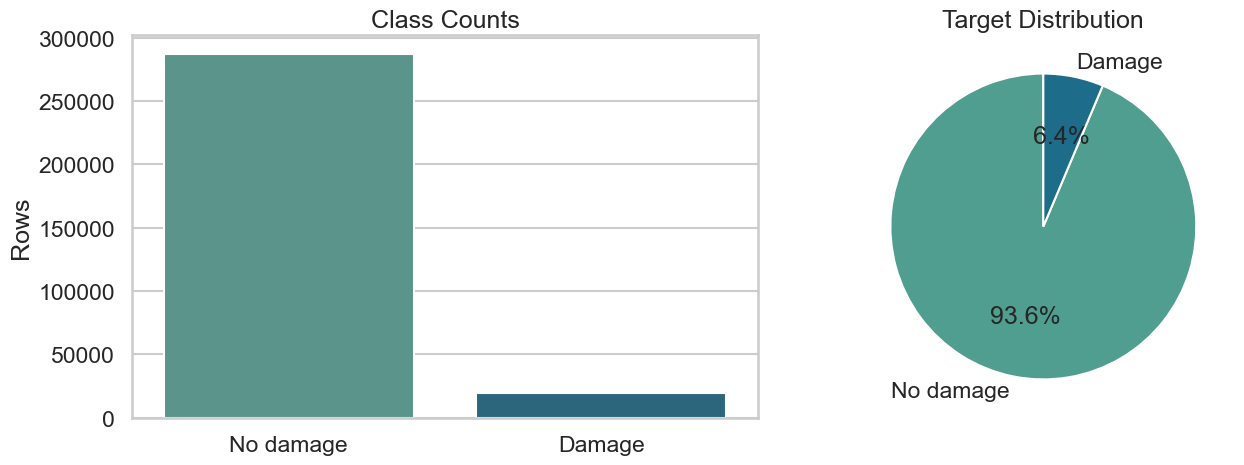

In [12]:
target_rate = train_df[target_col].mean()
summary = pd.DataFrame(
    {
        "train_rows": [len(train_df)],
        "test_rows": [len(test_df)],
        "n_features_train": [train_df.shape[1] - 1],
        "positive_rate": [target_rate],
        "negative_rate": [1 - target_rate],
        "majority_class_balanced_accuracy": [0.5],
    }
)

target_counts = train_df[target_col].value_counts().rename(index={0: "No damage", 1: "Damage"}).to_frame("count")
target_counts["share"] = target_counts["count"] / target_counts["count"].sum()

display(summary)
display(target_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=target_counts.index, y=target_counts["count"], ax=axes[0], palette="crest")
axes[0].set_title("Class Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

axes[1].pie(target_counts["share"], labels=target_counts.index, autopct="%.1f%%", startangle=90, colors=sns.color_palette("crest", 2))
axes[1].set_title("Target Distribution")
plt.tight_layout()
plt.show()

,dtype,missing_pct,nunique
BIRD_BAND_NUMBER,object,0.9977,612
ENG_4_POS,float64,0.9894,4
ENROUTE_STATE,object,0.9826,58
PRECIPITATION,object,0.9635,10
ENG_3_POS,float64,0.9598,5
LOCATION,object,0.8723,9230
SPEED,float64,0.6904,287
NUM_SEEN,object,0.6789,4
SKY,object,0.5301,3
FLT,object,0.5255,10649


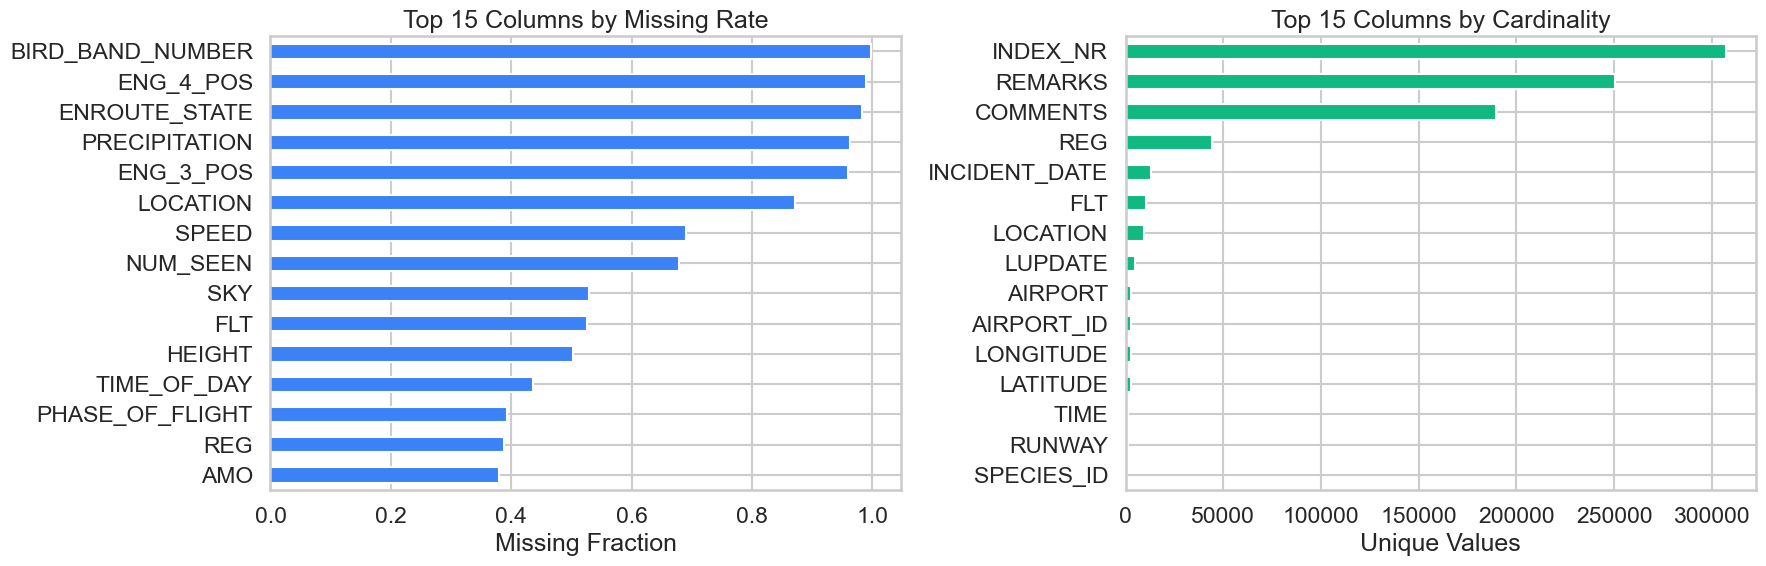

In [13]:
missing_pct = train_df.isna().mean().sort_values(ascending=False)
cardinality = train_df.drop(columns=[target_col]).nunique(dropna=True).sort_values(ascending=False)

audit_table = pd.concat(
    [
        train_df.dtypes.rename("dtype"),
        missing_pct.rename("missing_pct"),
        train_df.nunique(dropna=True).rename("nunique"),
    ],
    axis=1,
).sort_values(["missing_pct", "nunique"], ascending=[False, False])

display(audit_table.head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
missing_pct.head(15).sort_values().plot(kind="barh", ax=axes[0], color="#3b82f6")
axes[0].set_title("Top 15 Columns by Missing Rate")
axes[0].set_xlabel("Missing Fraction")

cardinality.head(15).sort_values().plot(kind="barh", ax=axes[1], color="#10b981")
axes[1].set_title("Top 15 Columns by Cardinality")
axes[1].set_xlabel("Unique Values")
plt.tight_layout()
plt.show()

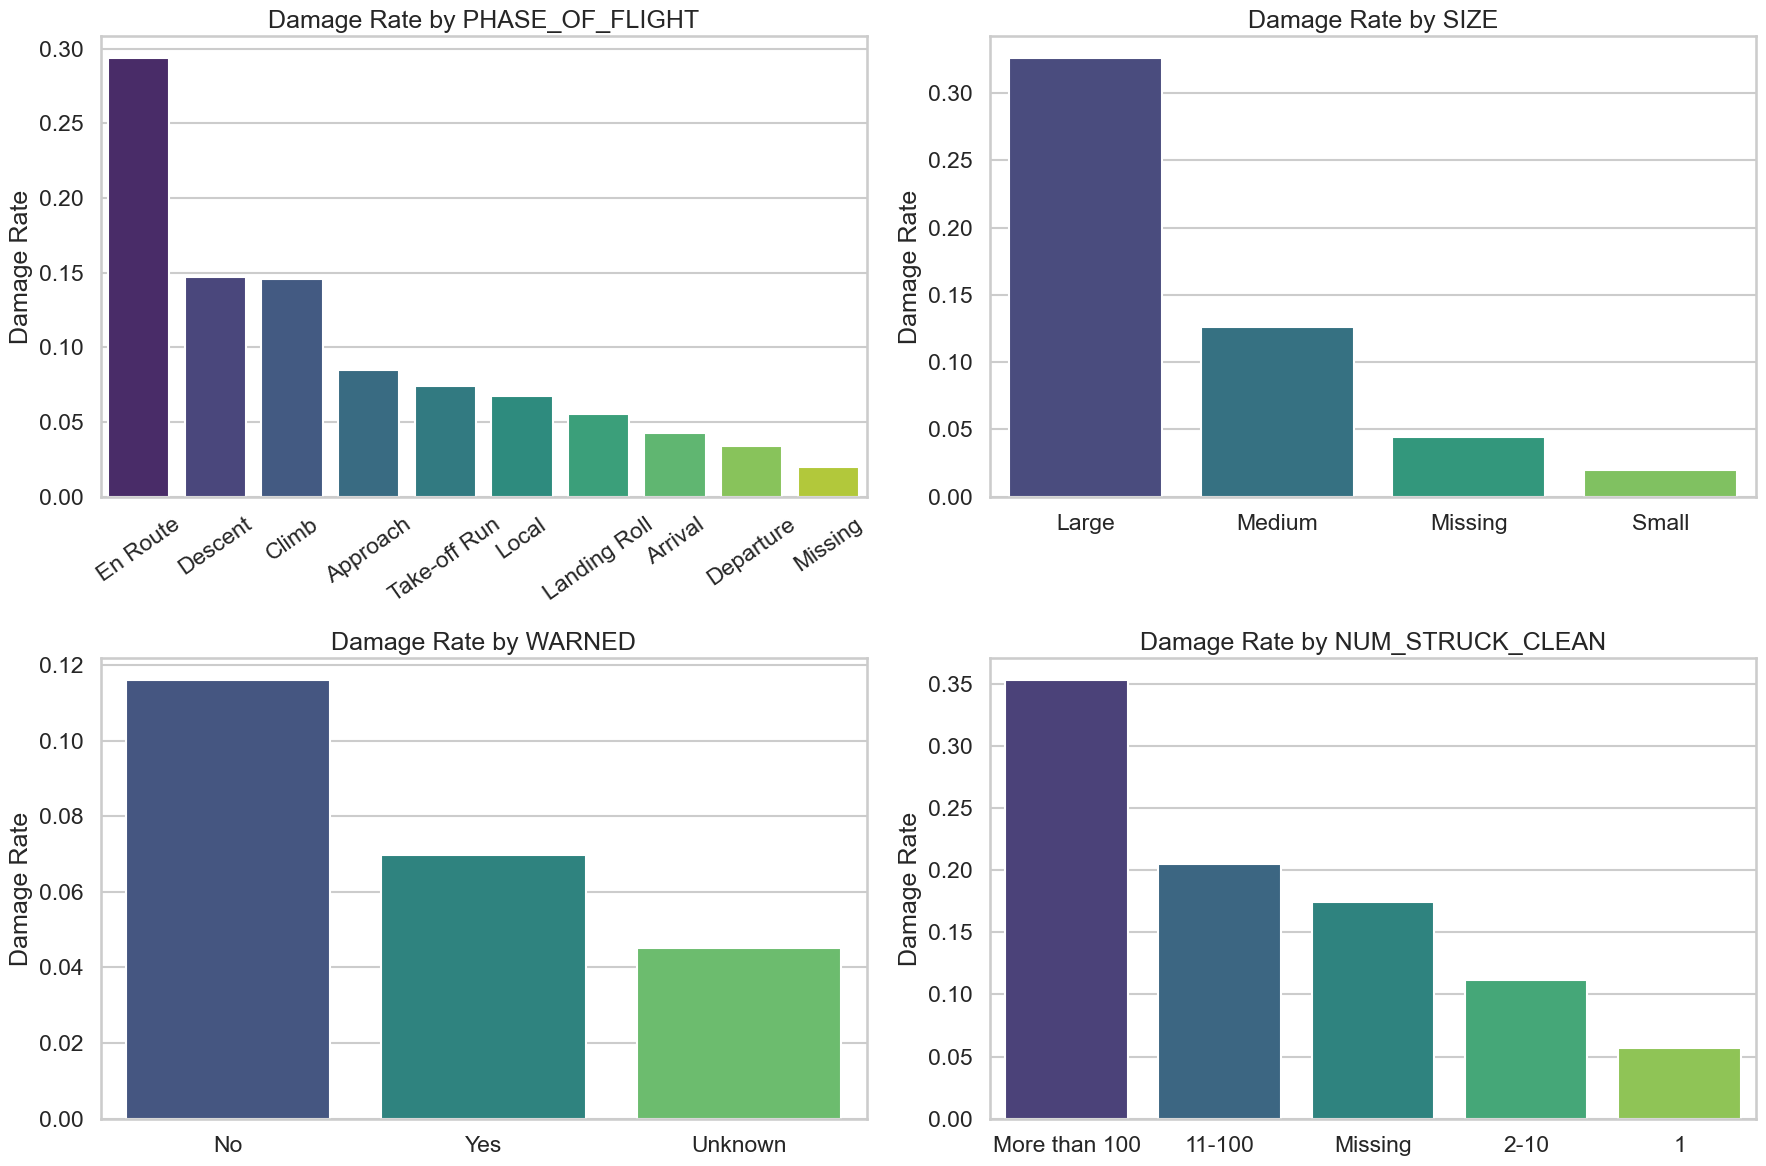

In [14]:
eda_df = train_df.copy()
eda_df["NUM_STRUCK_CLEAN"] = eda_df["NUM_STRUCK"].replace({"10-Feb": "2-10"})
eda_df["NUM_SEEN_CLEAN"] = eda_df["NUM_SEEN"].replace({"10-Feb": "2-10"})

def plot_damage_rate(ax, frame, column, top_n=None, rotate=0):
    plot_df = frame[[column, target_col]].copy()
    plot_df[column] = plot_df[column].fillna("Missing")
    if top_n is not None:
        top_values = plot_df[column].value_counts().head(top_n).index
        plot_df = plot_df[plot_df[column].isin(top_values)]
    rate_df = (
        plot_df.groupby(column)[target_col]
        .mean()
        .sort_values(ascending=False)
        .rename("damage_rate")
        .reset_index()
    )
    sns.barplot(data=rate_df, x=column, y="damage_rate", ax=ax, palette="viridis")
    ax.set_title(f"Damage Rate by {column}")
    ax.set_xlabel("")
    ax.set_ylabel("Damage Rate")
    ax.tick_params(axis="x", rotation=rotate)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plot_damage_rate(axes[0, 0], eda_df, "PHASE_OF_FLIGHT", top_n=10, rotate=35)
plot_damage_rate(axes[0, 1], eda_df, "SIZE")
plot_damage_rate(axes[1, 0], eda_df, "WARNED")
plot_damage_rate(axes[1, 1], eda_df, "NUM_STRUCK_CLEAN")
plt.tight_layout()
plt.show()

## Numeric Relationship Check

The bar plots above show categorical relationships with damage. We also check numeric relationships using a Spearman correlation heatmap because many variables are skewed, ordinal, or bucketed.

Main EDA takeaways used later:

- animal size and the number struck are clearly related to damage risk, which motivates ordinal strike-count and size features
- height, speed, and distance are skewed, so log transforms and missingness indicators are more useful than raw values alone
- no single numeric field explains the target by itself, which supports using non-linear models and engineered categorical features

,absolute_spearman_corr_with_damage
SIZE_ORD,0.3029
AC_MASS,0.1681
DISTANCE,0.1250
INCIDENT_YEAR,0.1229
REMAINS_COLLECTED,0.1184
HEIGHT,0.1124
NUM_ENGS,0.1082
NUM_SEEN_ORD,0.0892
NUM_STRUCK_ORD,0.0763
SPEED,0.0300


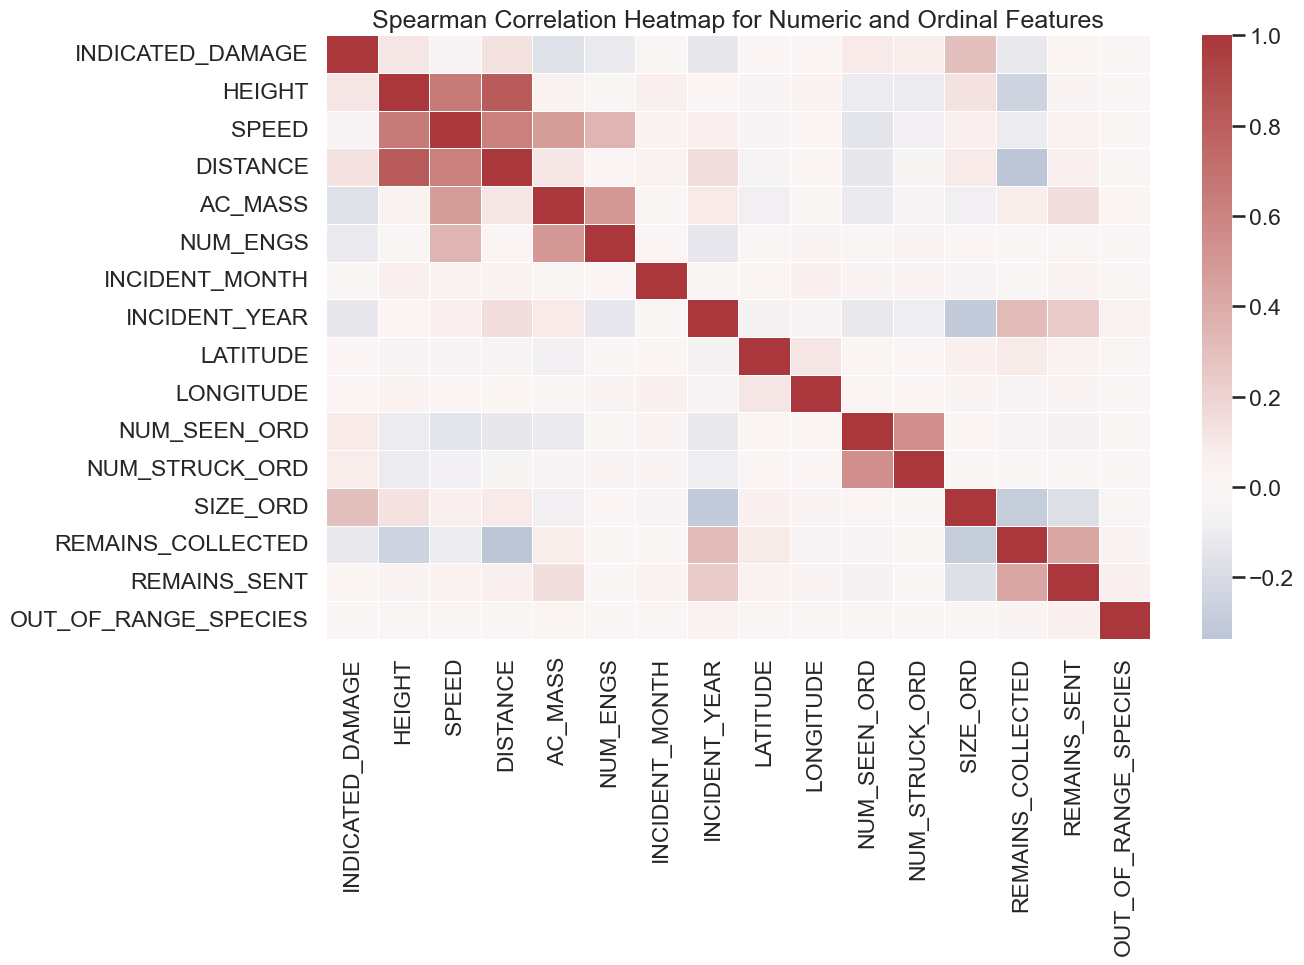

In [15]:
corr_count_map = {"1": 1.0, "10-Feb": 6.0, "11-100": 55.0, "More than 100": 150.0}
corr_size_map = {"Small": 1.0, "Medium": 2.0, "Large": 3.0}

corr_df = train_df.copy()
corr_df["LATITUDE"] = pd.to_numeric(corr_df["LATITUDE"], errors="coerce")
corr_df["LONGITUDE"] = pd.to_numeric(corr_df["LONGITUDE"], errors="coerce")
corr_df["NUM_SEEN_ORD"] = corr_df["NUM_SEEN"].map(corr_count_map)
corr_df["NUM_STRUCK_ORD"] = corr_df["NUM_STRUCK"].map(corr_count_map)
corr_df["SIZE_ORD"] = corr_df["SIZE"].map(corr_size_map)

correlation_cols = [
    target_col,
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "AC_MASS",
    "NUM_ENGS",
    "INCIDENT_MONTH",
    "INCIDENT_YEAR",
    "LATITUDE",
    "LONGITUDE",
    "NUM_SEEN_ORD",
    "NUM_STRUCK_ORD",
    "SIZE_ORD",
    "REMAINS_COLLECTED",
    "REMAINS_SENT",
    "OUT_OF_RANGE_SPECIES",
]

corr_matrix = corr_df[correlation_cols].corr(method="spearman")
target_corr = (
    corr_matrix[target_col]
    .drop(target_col)
    .abs()
    .sort_values(ascending=False)
    .rename("absolute_spearman_corr_with_damage")
    .to_frame()
)

display(target_corr.head(10))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="vlag", center=0, linewidths=0.5)
plt.title("Spearman Correlation Heatmap for Numeric and Ordinal Features")
plt.tight_layout()
plt.show()

## Cleaning and Feature Engineering Plan

The raw CSVs contain several issues we need to fix before modeling:

- blank strings and mixed data types (`LATITUDE`, `LONGITUDE`, `NUM_SEEN`, `NUM_STRUCK`)
- very high-cardinality identifiers (`AIRPORT_ID`, `SPECIES_ID`, `OPID`, `AIRCRAFT`, `RUNWAY`)
- important missingness patterns (`HEIGHT`, `SPEED`, `TIME`, `PHASE_OF_FLIGHT`, `TIME_OF_DAY`)
- strong class imbalance (`INDICATED_DAMAGE = 1` is only about 6.4%)

Feature engineering choices used below:

- parse date/time into cyclic calendar features
- convert `NUM_SEEN` / `NUM_STRUCK` from ordinal buckets into numeric proxies
- add missing-value indicators for key continuous columns
- split runway into numeric and side information
- create a kinetic-energy proxy using approximate animal size and speed squared
- one-hot encode lower-cardinality categories
- frequency encode higher-cardinality categories
- optionally keep **text metadata only** (presence/length of report narrative fields), while still avoiding raw text/NLP

To reduce obvious leakage and noise, we drop `INDEX_NR`, `TRANSFER`, `BIRD_BAND_NUMBER`, full free-text content, and several near-identifier fields that are not useful to interpret directly.

In [16]:
COUNT_MAP = {
    "1": 1.0,
    "10-Feb": 6.0,        # interpreted as the 2-10 bucket
    "11-100": 55.0,
    "More than 100": 150.0,
}

SIZE_MAP = {"Small": 1.0, "Medium": 2.0, "Large": 3.0}

DROP_COLS = [
    "INDEX_NR",
    "TRANSFER",
    "BIRD_BAND_NUMBER",
    "REG",
    "FLT",
    "REMARKS",
    "COMMENTS",
    "LOCATION",
    "LUPDATE",
    "AIRPORT",
    "OPERATOR",
    "SPECIES",
]


def replace_blank_strings(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    object_cols = frame.select_dtypes(include="object").columns
    for col in object_cols:
        frame[col] = frame[col].replace(r"^\s*$", np.nan, regex=True)
    return frame


def build_features(frame: pd.DataFrame, use_text_metadata: bool = True) -> pd.DataFrame:
    df = replace_blank_strings(frame)

    for col in ["LATITUDE", "LONGITUDE", "EMA", "EMO"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    incident_dt = pd.to_datetime(df["INCIDENT_DATE"], format="%m/%d/%y", errors="coerce")
    df["INCIDENT_DAYOFWEEK"] = incident_dt.dt.dayofweek
    df["INCIDENT_DAYOFYEAR"] = incident_dt.dt.dayofyear
    df["INCIDENT_QUARTER"] = incident_dt.dt.quarter
    df["IS_WEEKEND"] = incident_dt.dt.dayofweek.isin([5, 6]).astype(float)

    time_dt = pd.to_datetime(df["TIME"], format="%H:%M", errors="coerce")
    time_minutes = time_dt.dt.hour * 60 + time_dt.dt.minute
    df["TIME_MINUTES"] = time_minutes
    df["TIME_MISSING"] = time_minutes.isna().astype(int)
    time_angle = 2 * np.pi * time_minutes / 1440.0
    df["TIME_SIN"] = np.sin(time_angle)
    df["TIME_COS"] = np.cos(time_angle)

    for col in ["HEIGHT", "SPEED", "DISTANCE"]:
        series = pd.to_numeric(df[col], errors="coerce")
        df[col] = series
        df[f"{col}_MISSING"] = series.isna().astype(int)
        df[f"LOG_{col}"] = np.log1p(series.clip(lower=0))

    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        encoded = df[col].map(COUNT_MAP)
        df[f"{col}_ORD"] = encoded
        df[f"{col}_MISSING"] = df[col].isna().astype(int)
        df[f"{col}_MULTIPLE"] = encoded.fillna(0).gt(1).astype(int)

    df["SIZE_ORD"] = df["SIZE"].map(SIZE_MAP)
    df["KINETIC_ENERGY_PROXY"] = df["SIZE_ORD"].fillna(0) * (df["SPEED"].fillna(0).clip(lower=0) ** 2)
    df["WARNED_YES"] = df["WARNED"].eq("Yes").astype(int)
    df["WARNED_UNKNOWN"] = df["WARNED"].eq("Unknown").astype(int)
    df["AIRPORT_UNKNOWN"] = df["AIRPORT_ID"].eq("ZZZZ").astype(int)
    df["FOREIGN_LOCATION"] = df["STATE"].isin(["FN", "FGN"]).fillna(False).astype(int)
    df["ENROUTE_FLAG"] = df["ENROUTE_STATE"].notna().astype(int)
    df["GROUND_STRIKE"] = df["HEIGHT"].fillna(0).eq(0).astype(int)
    df["MULTI_ENGINE"] = pd.to_numeric(df["NUM_ENGS"], errors="coerce").fillna(0).ge(2).astype(int)

    runway = df["RUNWAY"].astype("string")
    df["RUNWAY_NUM"] = pd.to_numeric(runway.str.extract(r"(\d+)")[0], errors="coerce")
    df["RUNWAY_SUFFIX"] = runway.str.extract(r"([LRC])")[0].fillna("UNK")
    df["RUNWAY_KNOWN"] = runway.notna().astype(int)

    df["MONTH_SIN"] = np.sin(2 * np.pi * df["INCIDENT_MONTH"] / 12.0)
    df["MONTH_COS"] = np.cos(2 * np.pi * df["INCIDENT_MONTH"] / 12.0)

    if use_text_metadata:
        for col in ["REMARKS", "COMMENTS", "LOCATION"]:
            df[f"{col}_HAS_TEXT"] = df[col].notna().astype(int)
            df[f"{col}_LEN"] = df[col].fillna("").str.len()

    keep_cols = [
        col
        for col in df.columns
        if col not in DROP_COLS + ["INCIDENT_DATE", "TIME", "NUM_SEEN", "NUM_STRUCK"]
    ]
    return df[keep_cols]


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns.tolist()
        self.maps_ = {}
        for col in self.columns_:
            series = X[col].astype("string").fillna("__MISSING__")
            self.maps_[col] = series.value_counts(normalize=True)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = {}
        for col in self.columns_:
            series = X[col].astype("string").fillna("__MISSING__")
            out[f"{col}_freq"] = series.map(self.maps_[col]).fillna(0.0).astype(float)
        return pd.DataFrame(out, index=X.index)


def get_feature_groups(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    low_cardinality_cols = [col for col in categorical_cols if X[col].nunique(dropna=True) <= 30]
    high_cardinality_cols = [col for col in categorical_cols if col not in low_cardinality_cols]
    return numeric_cols, categorical_cols, low_cardinality_cols, high_cardinality_cols


def make_preprocessors(X: pd.DataFrame):
    numeric_cols, categorical_cols, low_cardinality_cols, high_cardinality_cols = get_feature_groups(X)

    numeric_scaled_steps = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    low_cardinality_steps = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=200,
                    sparse_output=False,
                ),
            ),
        ]
    )
    high_cardinality_steps = Pipeline(steps=[("freq", FrequencyEncoder())])

    numeric_only_pre = ColumnTransformer(
        transformers=[("num", numeric_scaled_steps, numeric_cols)],
        remainder="drop",
    )

    dense_mixed_pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            ("low_cat", low_cardinality_steps, low_cardinality_cols),
            ("high_cat", high_cardinality_steps, high_cardinality_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

    scaled_mixed_pre = ColumnTransformer(
        transformers=[
            ("num", numeric_scaled_steps, numeric_cols),
            ("low_cat", low_cardinality_steps, low_cardinality_cols),
            ("high_cat", high_cardinality_steps, high_cardinality_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

    return numeric_only_pre, dense_mixed_pre, scaled_mixed_pre

def find_best_threshold(y_true, scores, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.60, 45)
    score_grid = []
    for threshold in grid:
        preds = (scores >= threshold).astype(int)
        score_grid.append((balanced_accuracy_score(y_true, preds), threshold))
    return max(score_grid, key=lambda item: item[0])

In [17]:
X_train_full = build_features(train_df.drop(columns=[target_col]), use_text_metadata=USE_TEXT_METADATA)
X_test_full = build_features(test_df, use_text_metadata=USE_TEXT_METADATA)

y = train_df[target_col].copy()

numeric_only_pre, dense_mixed_pre, scaled_mixed_pre = make_preprocessors(X_train_full)
numeric_cols, categorical_cols, low_cardinality_cols, high_cardinality_cols = get_feature_groups(X_train_full)

feature_summary = pd.DataFrame(
    {
        "n_total_features_after_engineering": [X_train_full.shape[1]],
        "n_numeric_features": [len(numeric_cols)],
        "n_categorical_features": [len(categorical_cols)],
        "n_low_cardinality_categoricals": [len(low_cardinality_cols)],
        "n_high_cardinality_categoricals": [len(high_cardinality_cols)],
        "use_text_metadata": [USE_TEXT_METADATA],
    }
)

display(feature_summary)
display(X_train_full.head())

,n_total_features_after_engineering,n_numeric_features,n_categorical_features,n_low_cardinality_categoricals,n_high_cardinality_categoricals,use_text_metadata
0,78,57,21,12,9,True


,INCIDENT_MONTH,INCIDENT_YEAR,TIME_OF_DAY,AIRPORT_ID,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,OPID,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,SPECIES_ID,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,SIZE,ENROUTE_STATE,SOURCE,PERSON,INCIDENT_DAYOFWEEK,INCIDENT_DAYOFYEAR,INCIDENT_QUARTER,IS_WEEKEND,TIME_MINUTES,TIME_MISSING,TIME_SIN,TIME_COS,HEIGHT_MISSING,LOG_HEIGHT,SPEED_MISSING,LOG_SPEED,DISTANCE_MISSING,LOG_DISTANCE,NUM_SEEN_ORD,NUM_SEEN_MISSING,NUM_SEEN_MULTIPLE,NUM_STRUCK_ORD,NUM_STRUCK_MISSING,NUM_STRUCK_MULTIPLE,SIZE_ORD,KINETIC_ENERGY_PROXY,WARNED_YES,WARNED_UNKNOWN,AIRPORT_UNKNOWN,FOREIGN_LOCATION,ENROUTE_FLAG,GROUND_STRIKE,MULTI_ENGINE,RUNWAY_NUM,RUNWAY_SUFFIX,RUNWAY_KNOWN,MONTH_SIN,MONTH_COS,REMARKS_HAS_TEXT,REMARKS_LEN,COMMENTS_HAS_TEXT,COMMENTS_LEN,LOCATION_HAS_TEXT,LOCATION_LEN
0,12,1993,Day,TJSJ,18.4394,-66.0018,7,PR,ASO,AAL,B-727-200,148,11,34.0000,10.0000,A,4.0000,D,3.0000,5.0000,6.0000,5.0000,NaN,Approach,300.0000,145.0000,NaN,Some Cloud,NaN,UNKBS,0,1,0,No,Small,NaN,FAA Form 5200-7,Pilot,0,347,4,0.0000,NaN,1,NaN,NaN,0,5.7071,0,4.9836,1,NaN,6.0000,0,1,6.0000,0,1,1.0000,"21,025.0000",0,0,0,0,0,0,1,7,UNK,1,-0.0000,1.0000,1,23,0,0,0,0
1,2,2010,Night,WMKK,2.7456,101.7099,32R,FN,FGN,FDX,MD-11,583,39,22.0000,7.0000,A,4.0000,D,3.0000,1.0000,6.0000,1.0000,NaN,Approach,50.0000,NaN,0.0000,NaN,NaN,UNKBM,0,0,0,Unknown,Medium,NaN,FAA Form 5200-7-E,Air Transport Operations,0,32,1,0.0000,300.0000,0,0.9659,0.2588,0,3.9318,1,NaN,0,0.0000,NaN,1,0,1.0000,0,0,2.0000,0.0000,0,1,0,1,0,0,1,32,R,1,0.8660,0.5000,1,48,1,38,0,0
2,5,2012,Night,KSDF,38.1744,-85.7360,35L,KY,ASO,UPS,A-300,04A,1,34.0000,46.0000,A,4.0000,D,2.0000,1.0000,1.0000,NaN,NaN,Approach,"3,500.0000",240.0000,8.0000,NaN,NaN,UNKBL,0,0,0,No,Large,NaN,Air Transport Report,Air Transport Operations,2,130,2,0.0000,120.0000,0,0.5000,0.8660,0,8.1608,0,5.4848,0,2.1972,NaN,1,0,1.0000,0,0,3.0000,"172,800.0000",0,0,0,0,0,0,1,35,L,1,0.5000,-0.8660,1,246,1,66,0,0
3,10,2002,NaN,KLAX,33.9425,-118.4081,25R,CA,AWP,UNK,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NE120,0,1,0,Unknown,Medium,NaN,FAA Form 5200-7-E,Carcass Found,1,281,4,0.0000,NaN,1,NaN,NaN,1,NaN,1,NaN,0,0.0000,NaN,1,0,6.0000,0,1,2.0000,0.0000,0,1,0,0,0,1,0,25,R,1,-0.8660,0.5000,1,41,1,41,0,0
4,2,1997,Dawn,PHLI,21.9760,-159.3390,35,HI,AWP,1AAH,B-737-200,148,13,34.0000,10.0000,A,4.0000,D,2.0000,1.0000,1.0000,NaN,NaN,Landing Roll,0.0000,135.0000,0.0000,Some Cloud,NaN,R1101,0,0,0,No,Medium,NaN,Multiple,NaN,0,34,1,0.0000,NaN,1,NaN,NaN,0,0.0000,0,4.9127,0,0.0000,1.0000,0,0,1.0000,0,0,2.0000,"36,450.0000",0,0,0,0,0,1,1,35,UNK,1,0.8660,0.5000,1,16,1,46,0,0


## Feature Ablation: Text Metadata vs. Strict Incident-Only Features

I tested whether simple text **metadata** (presence/length only, never raw text content) helps the model. This is included as an explicit ablation because it improves leaderboard performance, but it is also the most debatable feature family from a causal point of view.

If you want the strictest possible modeling story for the walkthrough, set `USE_TEXT_METADATA = False` near the top and rerun the notebook.

In [18]:
def evaluate_text_metadata_ablation(train_frame, y, config):
    rows = []
    for use_text_metadata in [False, True]:
        X_variant = build_features(train_frame, use_text_metadata=use_text_metadata)
        _, pre_variant, _ = make_preprocessors(X_variant)

        X_tr, X_va, y_tr, y_va = train_test_split(
            X_variant,
            y,
            test_size=0.20,
            stratify=y,
            random_state=RANDOM_STATE,
        )

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        pipe = Pipeline(
            steps=[
                ("pre", pre_variant),
                ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE, **config)),
            ]
        )
        pipe.fit(X_tr, y_tr, model__sample_weight=weights)
        probs = pipe.predict_proba(X_va)[:, 1]
        best_score, best_threshold = find_best_threshold(y_va, probs)
        rows.append(
            {
                "use_text_metadata": use_text_metadata,
                "holdout_balanced_accuracy": best_score,
                "best_threshold": best_threshold,
                "n_engineered_features": X_variant.shape[1],
            }
        )
    return pd.DataFrame(rows).sort_values("holdout_balanced_accuracy", ascending=False)

text_ablation = evaluate_text_metadata_ablation(
    train_df.drop(columns=[target_col]),
    y,
    config=dict(max_iter=350, learning_rate=0.04, max_leaf_nodes=63, min_samples_leaf=60, l2_regularization=0.1),
)

display(text_ablation)

,use_text_metadata,holdout_balanced_accuracy,best_threshold,n_engineered_features
1,True,0.8421,0.4875,78
0,False,0.8321,0.4500,72


## Fast Model Screening on a Shared Holdout Split

Before doing heavier cross-validation, we compare a few candidate models on the same stratified train/validation split.

Models included:

- majority-class dummy baseline
- single decision tree baseline
- numeric-only logistic regression baseline
- random forest
- neural network MLP with L2 regularization through `alpha`
- histogram gradient boosting

The MLP is included because neural networks were part of the course and the assignment specifically mentions weight regularization. To keep the notebook runnable in a reasonable time, the MLP is trained on a stratified subset of the training fold and evaluated on the same validation fold as the other models. For probabilistic models, we tune the classification threshold on the validation split because Kaggle scores **balanced accuracy**, not plain accuracy.

In [19]:
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_full,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

screening_rows = []

# Dummy baseline
majority_preds = np.zeros(len(y_va), dtype=int)
screening_rows.append(
    {
        "model": "Dummy (predict all 0)",
        "balanced_accuracy": balanced_accuracy_score(y_va, majority_preds),
        "best_threshold": np.nan,
        "training_rows_used": len(X_tr),
    }
)

# Numeric-only logistic regression baseline
logistic_pipe = Pipeline(
    steps=[
        ("pre", numeric_only_pre),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_pipe.fit(X_tr, y_tr)
log_probs = logistic_pipe.predict_proba(X_va)[:, 1]
log_score, log_threshold = find_best_threshold(y_va, log_probs)
screening_rows.append(
    {
        "model": "Logistic Regression (numeric only)",
        "balanced_accuracy": log_score,
        "best_threshold": log_threshold,
        "training_rows_used": len(X_tr),
    }
)

candidate_models = [
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        dense_mixed_pre,
        False,
        None,
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        dense_mixed_pre,
        False,
        None,
    ),
    (
        "Neural Net (MLP, L2 regularized)",
        MLPClassifier(
            hidden_layer_sizes=(32,),
            alpha=0.01,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=5,
            batch_size=4096,
            max_iter=40,
            learning_rate_init=0.003,
            random_state=RANDOM_STATE,
        ),
        scaled_mixed_pre,
        True,
        30000,
    ),
    (
        "HistGradientBoosting",
        HistGradientBoostingClassifier(
            max_iter=220,
            learning_rate=0.06,
            max_leaf_nodes=63,
            min_samples_leaf=100,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        ),
        dense_mixed_pre,
        True,
        None,
    ),
]

for model_name, estimator, preprocessor, needs_sample_weight, max_train_rows in candidate_models:
    if max_train_rows is not None and len(X_tr) > max_train_rows:
        X_model_train, _, y_model_train, _ = train_test_split(
            X_tr,
            y_tr,
            train_size=max_train_rows,
            stratify=y_tr,
            random_state=RANDOM_STATE,
        )
    else:
        X_model_train = X_tr
        y_model_train = y_tr

    pipe = Pipeline(steps=[("pre", clone(preprocessor)), ("model", estimator)])
    fit_kwargs = {}
    if needs_sample_weight:
        fit_kwargs["model__sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_model_train)
    pipe.fit(X_model_train, y_model_train, **fit_kwargs)
    probs = pipe.predict_proba(X_va)[:, 1]
    best_score, best_threshold = find_best_threshold(y_va, probs)
    screening_rows.append(
        {
            "model": model_name,
            "balanced_accuracy": best_score,
            "best_threshold": best_threshold,
            "training_rows_used": len(X_model_train),
        }
    )

screening_results = pd.DataFrame(screening_rows).sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
display(screening_results)

,model,balanced_accuracy,best_threshold,training_rows_used
0,HistGradientBoosting,0.8398,0.4750,245742
1,Random Forest,0.8303,0.2000,245742
2,Decision Tree,0.8095,0.5125,245742
3,"Neural Net (MLP, L2 regularized)",0.8065,0.4750,30000
4,Logistic Regression (numeric only),0.8013,0.4750,245742
5,Dummy (predict all 0),0.5000,NaN,245742


## Cross-Validated Tuning for the Strongest Model Family

The holdout screen points to gradient boosting as the best direction, so we run a more careful **3-fold stratified CV** over a small set of strong boosting configurations.

This section stores out-of-fold probabilities for every configuration. That lets us:

- compare models using the same CV protocol
- choose a final threshold from OOF predictions
- test whether a simple ensemble beats the best single model

In [20]:
HGB_CONFIGS = {
    "hgb_a": dict(max_iter=250, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=80, l2_regularization=0.1),
    "hgb_b": dict(max_iter=350, learning_rate=0.04, max_leaf_nodes=63, min_samples_leaf=60, l2_regularization=0.1),
    "hgb_c": dict(max_iter=220, learning_rate=0.06, max_leaf_nodes=63, min_samples_leaf=100, l2_regularization=1.0),
}


def cross_validate_hgb_configs(X, y, configs, preprocessor, n_splits=3):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    results = []
    oof_predictions = {}

    for model_name, params in configs.items():
        fold_default_scores = []
        oof_probs = np.zeros(len(X))

        for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_fold_train = X.iloc[train_idx]
            X_fold_valid = X.iloc[valid_idx]
            y_fold_train = y.iloc[train_idx]
            y_fold_valid = y.iloc[valid_idx]

            sample_weight = compute_sample_weight(class_weight="balanced", y=y_fold_train)
            pipe = Pipeline(
                steps=[
                    ("pre", clone(preprocessor)),
                    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE, **params)),
                ]
            )
            pipe.fit(X_fold_train, y_fold_train, model__sample_weight=sample_weight)

            fold_probs = pipe.predict_proba(X_fold_valid)[:, 1]
            oof_probs[valid_idx] = fold_probs
            fold_default_scores.append(
                balanced_accuracy_score(y_fold_valid, (fold_probs >= 0.5).astype(int))
            )

        tuned_score, tuned_threshold = find_best_threshold(y, oof_probs)
        default_score = balanced_accuracy_score(y, (oof_probs >= 0.5).astype(int))

        results.append(
            {
                "model": model_name,
                "oof_balanced_accuracy_default_threshold": default_score,
                "oof_balanced_accuracy_tuned_threshold": tuned_score,
                "best_threshold": tuned_threshold,
                "fold_mean_default_threshold": np.mean(fold_default_scores),
                "fold_std_default_threshold": np.std(fold_default_scores),
            }
        )
        oof_predictions[model_name] = oof_probs

    result_df = pd.DataFrame(results).sort_values(
        "oof_balanced_accuracy_tuned_threshold", ascending=False
    ).reset_index(drop=True)
    return result_df, oof_predictions

cv_results, oof_predictions = cross_validate_hgb_configs(
    X_train_full,
    y,
    HGB_CONFIGS,
    dense_mixed_pre,
    n_splits=3,
)

display(cv_results)

,model,oof_balanced_accuracy_default_threshold,oof_balanced_accuracy_tuned_threshold,best_threshold,fold_mean_default_threshold,fold_std_default_threshold
0,hgb_c,0.8365,0.8379,0.4625,0.8365,0.0015
1,hgb_b,0.8363,0.8374,0.4750,0.8363,0.0018
2,hgb_a,0.8372,0.8374,0.4875,0.8372,0.0013


In [12]:
ensemble_rows = []
for combo in [
    ("hgb_a",),
    ("hgb_b",),
    ("hgb_c",),
    ("hgb_a", "hgb_c"),
    ("hgb_b", "hgb_c"),
    ("hgb_a", "hgb_b", "hgb_c"),
]:
    avg_probs = np.mean([oof_predictions[name] for name in combo], axis=0)
    score, threshold = find_best_threshold(y, avg_probs)
    ensemble_rows.append(
        {
            "ensemble": " + ".join(combo),
            "oof_balanced_accuracy": score,
            "best_threshold": threshold,
        }
    )

ensemble_results = pd.DataFrame(ensemble_rows).sort_values("oof_balanced_accuracy", ascending=False).reset_index(drop=True)
display(ensemble_results)

,ensemble,oof_balanced_accuracy,best_threshold
0,hgb_a + hgb_c,0.8382,0.4750
1,hgb_a + hgb_b + hgb_c,0.8382,0.5000
2,hgb_b + hgb_c,0.8379,0.4750
3,hgb_b,0.8377,0.4500
4,hgb_a,0.8377,0.4625
5,hgb_c,0.8373,0.4500


,metric,value
0,OOF balanced accuracy,0.8379
1,Recall for damage = 1,0.8315
2,Recall for no damage = 0,0.8442
3,Predicted positive rate,0.1988


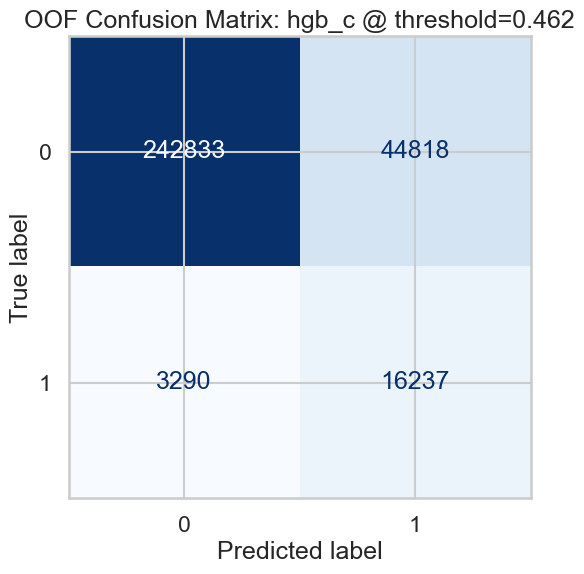

In [28]:
best_model_row = cv_results.iloc[0]
best_model_name = best_model_row["model"]
best_threshold = float(best_model_row["best_threshold"])
best_oof_probs = oof_predictions[best_model_name]
best_oof_preds = (best_oof_probs >= best_threshold).astype(int)

summary_metrics = pd.DataFrame(
    {
        "metric": [
            "OOF balanced accuracy",
            "Recall for damage = 1",
            "Recall for no damage = 0",
            "Predicted positive rate",
        ],
        "value": [
            balanced_accuracy_score(y, best_oof_preds),
            recall_score(y, best_oof_preds, pos_label=1),
            recall_score(y, best_oof_preds, pos_label=0),
            best_oof_preds.mean(),
        ],
    }
)

display(summary_metrics)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y, best_oof_preds)).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"OOF Confusion Matrix: {best_model_name} @ threshold={best_threshold:.3f}")
plt.show()

## Final Model Choice

The final competition model is the single configuration with the best **OOF balanced accuracy**. If an ensemble had beaten it on OOF predictions, we would have used the ensemble instead, but in this notebook the simpler single model is the most reliable choice.

In [29]:
FINAL_PARAMS = HGB_CONFIGS[best_model_name]
final_model = Pipeline(
    steps=[
        ("pre", clone(dense_mixed_pre)),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE, **FINAL_PARAMS)),
    ]
)

final_sample_weight = compute_sample_weight(class_weight="balanced", y=y)
final_model.fit(X_train_full, y, model__sample_weight=final_sample_weight)

test_probs = final_model.predict_proba(X_test_full)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

submission = sample_submission.copy()
submission["INDICATED_DAMAGE"] = test_preds.astype(int)

print(f"Chosen model: {best_model_name}")
print(f"Final threshold: {best_threshold:.3f}")
print(f"Predicted damage rate on test: {submission['INDICATED_DAMAGE'].mean():.4f}")
display(submission.head())


if SAVE_SUBMISSION:
    output_path = DATA_DIR / "submission_hist_gradient_boosting.csv"
    submission.to_csv(output_path, index=False)
    print(f"Saved submission to {output_path.resolve()}")
else:
    print("SAVE_SUBMISSION is False, so no CSV was written.")

Chosen model: hgb_c
Final threshold: 0.462
Predicted damage rate on test: 0.2013


,INDEX_NR,INDICATED_DAMAGE
0,9000000,0
1,9000001,0
2,9000002,0
3,9000003,0
4,9000004,0


Saved submission to C:\Users\aaron\fnalproj ML - Copy\submission_hist_gradient_boosting.csv


## Final Takeaways

- The class imbalance is severe, so **balanced accuracy + threshold tuning** matters a lot.
- Feature engineering provided a large boost: temporal features, strike-count mappings, missingness indicators, runway parsing, a kinetic-energy proxy, and high-cardinality encodings all helped.
- We tried a course-aligned neural network with L2 regularization (`MLPClassifier(alpha=0.01)`) on a stratified training subset, but the boosted tree model performed better on this tabular dataset.
- In both holdout screening and cross-validated tuning, **gradient boosting** was the strongest model family.
- The best final configuration was selected by **OOF balanced accuracy**, not by a single lucky split.
- The notebook keeps the workflow reproducible and presentation-friendly for the project walkthrough.